# Research Agent API - Synchronous Client

A robust Python client for the [Bigdata.com Research Agent API](https://docs.bigdata.com/how-to-guides/agents) that consumes the Server-Sent Events stream and hands back one finished result: the answer, correctly attributed citations, and any charts the agent produced.

## Features

| Feature | Description |
|---------|-------------|
| **Synchronous interface** | One blocking call - no async/await |
| **Complete message coverage** | Every public SSE message type is handled; unknown types are ignored so new API versions do not break the client |
| **Accurate citations** | Document citations and whole-tool attributions are handled separately, so a reference never renders as a blank `N/A` entry |
| **Typed errors** | HTTP status codes and in-stream `ERROR` events map to specific exception classes |
| **Automatic retries** | Exponential backoff with jitter for `429`, `5xx`, and transient network failures |
| **Charts** | `CHART` events are collected as Vega-Lite specs anchored to answer offsets |
| **Conversation continuity** | `chat_id` follow-ups and `checkpoint_id` branching |

## Reference documentation

- [Concepts overview](https://docs.bigdata.com/how-to-guides/agents/concepts/overview)
- [Streaming responses](https://docs.bigdata.com/how-to-guides/agents/concepts/streaming-responses)
- [Grounding and citations](https://docs.bigdata.com/how-to-guides/agents/concepts/grounding-and-citations)
- [Code execution and charts](https://docs.bigdata.com/how-to-guides/agents/concepts/code-execution-and-charts)
- [Error handling](https://docs.bigdata.com/how-to-guides/agents/concepts/error-handling)

---
## 1. Setup

The client needs `requests` and a `BIGDATA_API_KEY`. Everything else is standard library.

In [1]:
import json
import logging
import os

from IPython.display import Markdown, display

from research_client import ResearchClient, format_source_date, setup_logging

os.makedirs("output", exist_ok=True)

# Logging is flushed on every record, so the log file survives a hard failure
# mid-stream. Set console=False to keep the notebook output quiet.
setup_logging(
    log_file="output/research_client.log",
    level=logging.INFO,
    console=False,
    file_mode="w",
)

print("Ready.")

Ready.


---
## 2. Configure the client

Retry, timeout, and tool settings are all set once on the client. Per-request overrides are available on `research()`.

| Parameter | Default | Description |
|-----------|---------|-------------|
| `timeout` | `300` | Connection timeout in seconds |
| `stream_timeout` | `60.0` | Max seconds to wait between SSE chunks before treating the connection as stalled |
| `max_retries` | `3` | Retry attempts for transient failures |
| `retry_delay` | `1.0` | Initial backoff delay |
| `retry_backoff` | `2.0` | Exponential backoff multiplier |
| `retry_max_delay` | `60.0` | Upper bound on the backoff delay |
| `persistence_mode` | `"enabled"` | Saves conversation history so `chat_id` follow-ups work. The API itself defaults to `"disabled"` |
| `code_execution` | `None` | Whether the agent may run sandboxed Python. `None` keeps the server default (on) |
| `chart_generation` | `None` | Whether the agent may emit `CHART` events. `None` keeps the server default (off) |

Backoff uses **full jitter** (`delay + random(0, delay)`), which is the pattern the
[error handling guide](https://docs.bigdata.com/how-to-guides/agents/concepts/error-handling#retry-and-backoff) recommends for `429` and `5xx`.

In [2]:
client = ResearchClient(
    # Timeouts
    timeout=300,
    stream_timeout=90.0,
    # Retries
    max_retries=3,
    retry_delay=2.0,
    retry_backoff=2.0,
    retry_max_delay=60.0,
    # Conversation history, required for follow_up()
    persistence_mode="enabled",
    # Let the agent run Python and draw charts
    code_execution=True,
    chart_generation=True,
)

print("Client configured.")

Client configured.


### Demonstrate retries

Transient failures such as a dropped connection, a `429`, or a `5xx` are retried automatically with exponential backoff and full jitter. Permanent client errors (`400`, `401`, `403`, `404`) are raised immediately.

A live outage is rare while you are reading this notebook, so the cell below **injects one retryable failure** on the first `requests.post`, then lets the real call through. Watch for the `Retryable error` / `Retry 1/3` log lines.

In [3]:
import logging
from unittest.mock import patch

from requests.exceptions import ConnectionError as RequestsConnectionError

from research_client import logger as research_logger

# Short delays so the demo finishes quickly; the main `client` above keeps the
# production-style retry profile for the rest of the notebook.
retry_demo_client = ResearchClient(
    timeout=300,
    stream_timeout=90.0,
    max_retries=3,
    retry_delay=0.5,
    retry_backoff=2.0,
    retry_max_delay=5.0,
    persistence_mode="enabled",
)

# Surface retry warnings in the notebook output for this cell only.
console = logging.StreamHandler()
console.setLevel(logging.WARNING)
console.setFormatter(logging.Formatter("%(levelname)s - %(message)s"))
research_logger.addHandler(console)

call_count = {"n": 0}
real_post = __import__("requests").post


def flaky_post(*args, **kwargs):
    """Fail once with a retryable network error, then behave normally."""
    call_count["n"] += 1
    if call_count["n"] == 1:
        raise RequestsConnectionError("simulated dropped connection (demo)")
    return real_post(*args, **kwargs)


print("Forcing a ConnectionError on attempt 1, then succeeding...\n")

with patch("requests.post", side_effect=flaky_post):
    retry_demo = retry_demo_client.research(
        message="What is the current level of the Nasdaq 100?",
        research_effort="lite",
    )

research_logger.removeHandler(console)

print(f"\nHTTP attempts: {call_count['n']}  (1 failure + 1 success)")
print(f"Answer length: {len(retry_demo.answer):,} characters")
print(f"Processing time: {retry_demo.processing_time_ms}ms")
print("Retry path exercised successfully.")

WARNING - Retryable error on attempt 1/4: ConnectionError: simulated dropped connection (demo)


WARNING - Retry 1/3 in 0.6s


Forcing a ConnectionError on attempt 1, then succeeding...




HTTP attempts: 2  (1 failure + 1 success)
Answer length: 83 characters
Processing time: 13009ms
Retry path exercised successfully.


---
## 3. Run a research query

The agent streams typed events while it works. Passing an `on_event` callback lets you show progress without dealing with the stream yourself.

A `research_effort` of `"lite"` returns in roughly 10-20 seconds; `"standard"` runs multi-step research and takes 20-60 seconds.

In [75]:
QUERY = "How is Nasdaq 100 Performing?"


def make_progress_printer():
    """
    Build an `on_event` callback that prints a compact progress line per event.

    PLANNING resends the whole plan every time it changes, so already-reported
    steps are suppressed rather than reprinted.
    """
    reported: set[str] = set()

    def show_progress(msg_type: str, msg: dict) -> None:
        if msg_type == "PLANNING":
            for step in msg.get("plan", {}).get("steps", []):
                line = f"  [{step.get('status', '').lower()}] {step.get('description')}"
                if step.get("status") in ("IN_PROGRESS", "COMPLETED") and line not in reported:
                    reported.add(line)
                    print(line)
        elif msg_type == "ACTION":
            print(f"  action: {msg.get('tool_name')}")
        elif msg_type == "CHART":
            print(f"  chart: {msg.get('title')} ({msg.get('chart_type')})")
        elif msg_type == "TOOL_ERROR":
            print(f"  tool error: {msg.get('tool_name')} - {msg.get('error')}")
        elif msg_type == "LLM_RETRY":
            print(f"  agent retrying: {msg.get('message')}")

    return show_progress


print(f"Researching: {QUERY}\n")

result = client.research(
    message=QUERY,
    research_effort="standard",
    on_event=make_progress_printer(),
)

print(f"\nDone in {result.processing_time_ms / 1000:.1f}s")
print(f"  answer:         {len(result.answer):,} characters")
print(f"  documents:      {len(result.citations)}")
print(f"  grounded spans: {len(result.grounding_refs)}")
print(f"  charts:         {len(result.charts)}")
print(f"  tool errors:    {result.tool_errors or 'none'}")
print(f"  chat_id:        {result.chat_id}")
print(f"  checkpoint_id:  {result.checkpoint_id}")

Researching: How is Nasdaq 100 Performing?

  action: search_companies
  action: get_market_tearsheet
  action: search
  action: search
  [completed] Gather market overview and Nasdaq 100 performance metrics.
  [completed] Identify current top constituents of the Nasdaq 100 and gather their recent performance and sentiment.
  [completed] Research key drivers: sector performance, macro factors, and specific news impacting top constituents.
  [completed] Gather market sentiment and outlook for the Nasdaq 100.
  [completed] Synthesize findings into the final report.

Done in 73.2s
  answer:         4,023 characters
  documents:      32
  grounded spans: 19
  charts:         0
  tool errors:    none
  chat_id:        1785347283-7716a551-a63b-4b57-9e81-a733cddd6aad
  checkpoint_id:  1f18b75c-f8cd-6074-801b-ea6a43218406


---
## 4. Answer with inline citations

`GROUNDING` events attribute spans of the answer to their sources using `start`/`end` character offsets into the **cumulative** answer text. The client buffers every `ANSWER` chunk verbatim and only resolves those offsets once the stream is complete, which is the rule the [grounding guide](https://docs.bigdata.com/how-to-guides/agents/concepts/grounding-and-citations#the-buffering-rule) sets out.

Two kinds of reference come back, and they need different rendering:

| `source` | Meaning | Rendered as |
|---|---|---|
| Populated | A document returned by the **search** tool | Headline, publisher, date, and URL |
| Absent | Every **other** tool (market tearsheet, earnings calendar, code execution) grounds the span at the whole-tool level via `audit_id` | The tool's audit title, e.g. *Market Tearsheet* |

Treating the second kind as a document is what produced blank `N/A` citations. The client now resolves it against the matching `AUDIT` trace instead.

In [71]:
def print_citation(numbered_citations):
    for citation in numbered_citations:
        number = citation["number"]

        if citation.get("type") == "TOOL":
            # Whole-tool attribution: no document, so label it with the audit title.
            title = citation.get("title") or citation["tool_name"]
            parts = [
                f"**[{number}]** {title}",
                f"Bigdata.com tool &nbsp;`{citation['tool_name']}`",
            ]
            display(Markdown("<br>".join(parts) + "\n\n---"))
            continue

        source = citation.get("source") or {}
        parts = [f"**[{number}]** {citation.get('headline', '')}".rstrip()]

        meta = []
        if source.get("name"):
            meta.append(source["name"])
        if citation.get("timestamp"):
            meta.append(format_source_date(citation["timestamp"]))
        if meta:
            parts.append(" &nbsp;|&nbsp; ".join(meta))
        if citation.get("url"):
            parts.append(f"[{citation['url'][:70]}]({citation['url']})")

        excerpts = [c.get("text", "") for c in citation.get("chunks", [])[:2]]
        body = "<br>".join(parts)
        for excerpt in excerpts:
            if excerpt:
                trimmed = excerpt.replace("\n", " ")[:300]
                body += f"\n\n> *{trimmed}...*"

        display(Markdown(body + "\n\n---"))

In [76]:
answer_with_citations = result.get_answer_with_citations()
numbered_citations = result.get_numbered_citations()

display(Markdown("## Answer\n\n" + answer_with_citations))

display(Markdown(f"---\n## References ({len(numbered_citations)})\n"))
print_citation(numbered_citations)

## Answer

### Executive Summary
The Nasdaq 100 index is experiencing a period of heightened volatility, reflecting a broader structural rotation away from the tech-heavy concentration that drove the first-half gains of 2026. As of July 29, 2026, the index sits at 27,534.46, with significant downward pressure in the last month (-7.52%) as investors reassess the durability of AI-driven earnings and broader macroeconomic risks. While year-to-date performance remains positive at 9.05%, the market is currently pivoting, with heightened scrutiny on upcoming mega-cap earnings reports and a notable shift in sentiment toward more defensive or diversified exposure.

### Performance Metrics

| Timeframe | Performance (%) |
| :--- | :--- |
| **Year-to-Date (YTD)** | +9.05% |
| **1-Month** | -7.52% |
| **1-Year** | +18.13% |

*Source: Market Data as of July 29, 2026 [1]*

### Core Drivers

**1. Constituent Concentration & The SpaceX Addition**
The index's performance remains heavily tethered to its top 10 constituents, which account for approximately 45% of the total index weighting [2]. This high concentration leaves the Nasdaq 100 particularly sensitive to sentiment shifts within the "AI trade." A notable development in July 2026 was the inclusion of SpaceX into the index on July 7 [3]. Despite its massive total market capitalization, SpaceX’s weight in the index is relatively modest—estimated at approximately 1.3%–1.4%—due to the index's free-float methodology [4, 5, 6]. While its addition generated significant interest, analysts generally view its near-term impact on overall index volatility as secondary to the established mega-cap anchors like Nvidia, Apple, and Microsoft [6].

**2. Sector Performance & Rotation**
Technology and semiconductor sectors, which dominated the rally through the first half of 2026, have faced a significant correction in July. The XLK technology ETF has seen an 8.84% decline over the past month [1], fueled by investor anxiety over the massive capital expenditure (capex) dedicated to AI and the sustainability of those growth rates. In contrast, there is increasing institutional commentary regarding a "broadening" of leadership, where capital is beginning to rotate toward sectors like consumer staples and communication services, which have shown more resilience during the recent downturn [7, 8, 9].

**3. Macroeconomic Influences**
The index is currently navigating a complex macro environment. Geopolitical tensions, particularly involving the US and Iran, have added pressure on energy costs and overall market sentiment [10, 11]. Furthermore, the "AI-supercycle" narrative is being stress-tested by interest rate expectations. While the Fed is generally expected to hold rates steady, uncertainty regarding future policy, coupled with concerns that high AI capex is diverting liquidity from share buybacks, has created a more cautious backdrop for high-valuation growth stocks [10, 12].

### Market Sentiment & Outlook
Prevailing market sentiment is characterized by "structural anxiety" regarding the tech rally. Options markets are reflecting this, with the spread between the tech-heavy volatility index ($VXN) and the broader market $VIX widening to levels not seen since the 2008 financial crisis, signaling that investors are pricing in significantly more risk for technology stocks than for the broader market [13]. 

Expert commentary remains cautiously optimistic on long-term earnings potential, noting that while technical levels are fracturing, corporate fundamentals—specifically EPS growth—remain robust compared to the S&P 500 [13]. The near-term outlook is highly dependent on the Q2 earnings season, with heavy emphasis on the reports from major index leaders (Microsoft, Meta, Apple, Amazon). Many analysts, including those from UBS, suggest that the next phase of equity gains will likely require a broadening of market leadership beyond the technology sector, implying that the Nasdaq 100 may experience a period of consolidation or "valuation resetting" as the market digestion of AI-driven growth continues [14, 15].

---
## References (15)


**[1]** Market Tearsheet<br>Bigdata.com tool &nbsp;`get_market_tearsheet`

---

**[2]** How do the portfolio adjustments of actively managed funds differ given the concentration of U.S. tech giants?<br>Sina (新浪) &nbsp;|&nbsp; Jul 24, 2026<br>[http://cj.sina.com.cn/articles/view/5570287027/14c03d5b300101nxy8](http://cj.sina.com.cn/articles/view/5570287027/14c03d5b300101nxy8)

> *In the first half of 2026, the Nasdaq 100 index rose by approximately 20%, but the vast majority of these gains came from just 10 stocks. Micron Technology alone contributed over a quarter of the index's return. This phenomenon is driven by the highly concentrated weighting of the Nasdaq 100 index. ...*

---

**[3]** SpaceX set to join Nasdaq 100 in July<br>ArabianBusiness.com &nbsp;|&nbsp; Jun 27, 2026<br>[https://www.arabianbusiness.com/business/industries/spacex-nasdaq-100-](https://www.arabianbusiness.com/business/industries/spacex-nasdaq-100-july)

> *Fast entry rule pulls SpaceX into benchmark Nasdaq's May 2026 rule rewrite created the route SpaceX is using. Nasdaq 100 methodology records that any non-constituent ranking within the top 40 current index members by full market capitalisation can enter on a fast entry basis. Nasdaq evaluates an IPO...*

---

...

**[11]** Forex Bulletin - 07.20.2026<br>Gedik Investment Securities &nbsp;|&nbsp; Jul 20, 2026<br>[https://research.bluematrix.com/docs/pdf/90be6b15-c069-45dc-b7d1-ddf8c](https://research.bluematrix.com/docs/pdf/90be6b15-c069-45dc-b7d1-ddf8ce63aad6/66689781-4282-423b-8048-0a94967cc2e6)

> *Nasdaq Near Term The Nasdaq index completed the past week with a 2.9% decrease, influenced by sharp sell-offs in semiconductor stocks, and started the new week with a flat outlook. The escalating tensions between the US and Iran are increasing inflation and interest rate hike concerns, leading to co...*

---

**[12]** The NAGA Group AG - NASDAQ 100 Forecast & Price Predictions 2026: Breakout towards 28,000<br>PubT &nbsp;|&nbsp; Jan 08, 2026<br>[https://naga.com/eu/news-and-analysis/articles/nasdaq-100-price-predic](https://naga.com/eu/news-and-analysis/articles/nasdaq-100-price-prediction)

> *Institutional NASDAQ-100 forecast 2026 While some analysts highlight the resilience of companies and the market's capacity to handle challenges, others caution about the uncertainty in the economic outlook and possible volatility. Overall, there is a positive NASDAQ-100 forecast for 2026, accompanie...*

> *Nasdaq-100 Price Predictions by Components (Top 10) NASDAQ-100 price predictions are based on its components' price predictions which we'll review below. The list includes 10 components sorted by each component's weight in the index. |Microsoft Corp (27%) The 34 analysts offering 12-month price fore...*

---

**[13]** Nasdaq 100 Flashes Warning Signs After 5-Day Slide: Is The Tech Rally Running Out Of Steam?<br>Benzinga &nbsp;|&nbsp; Jun 29, 2026<br>[https://www.benzinga.com/node/60149061?utm_campaign=partner_feed&utm_m](https://www.benzinga.com/node/60149061?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack)

> *The 10 best-performing stocks in the Nasdaq 100 in 2026. This structural anxiety is compounded by immense sector concentration, with semiconductor giants like SanDisk Corp. (NASDAQ:SNDK), Micron Technology Inc. (NASDAQ:MU), and Intel Corp. (NASDAQ:INTC) completely dominating the index's top performe...*

---

**[14]** Traders on Kalshi think the Nasdaq-100 will end 2026 above 30,000, predicting a cooler second half of the year<br>CNBC &nbsp;|&nbsp; Jul 07, 2026<br>[https://www.cnbc.com/2026/07/07/traders-on-kalshi-think-the-nasdaq-100](https://www.cnbc.com/2026/07/07/traders-on-kalshi-think-the-nasdaq-100-will-end-2026-above-30000.html)

> *The Nasdaq-100's big run up in 2026 came after the U.S. stock market hit its Iran war-induced lows on March 30. Between then and June 2, the index, comprised of the 100 largest non-financial stocks on Nasdaq, surged more than 33% amid renewed confidence in the artificial intelligence trade. Fading c...*

> *The Nasdaq-100 will end the year above 30,000, Kalshi traders estimate, a level not much higher than where the tech-heavy index was trading in midday trading Tuesday. Traders are not confident that the index will break out to highs above 32,000 this year. The Nasdaq-100 is up about 18% in 2026, but ...*

---

**[15]** Kalshi traders believe the Nasdaq 100 will close above 30,000 by the end of 2026, forecasting a slower second half.<br>Sina (新浪) &nbsp;|&nbsp; Jul 07, 2026<br>[https://finance.sina.com.cn/stock/usstock/c/2026-07-08/doc-inifzshq495](https://finance.sina.com.cn/stock/usstock/c/2026-07-08/doc-inifzshq4959492.shtml)

> *Confidence wanes But traders now seem to think the bull run has lost steam. Another contract suggests there is a 40% chance the Nasdaq 100 Index will close above 32,000 in 2026. So far, the index’ s intraday high this year was 30,762, reached on June 3. Traders believe there is only about a 27% chan...*

> *The Nasdaq 100 Index has risen about 18% in 2026, but traders on the Kalshi prediction market believe the index will not see significant gains in the second half of 2026. Speculators believe there is about a 50% chance the tech-heavy index will close above 30,000 by the end of 2026, a level it first...*

---

### Verify: no blank references

Every entry must resolve to either a document headline or a tool title.

In [77]:
blank = [
    c
    for c in numbered_citations
    if not (c.get("headline") or c.get("title") or c.get("tool_name"))
]
tool_level = [c for c in numbered_citations if c.get("type") == "TOOL"]

print(f"total references:  {len(numbered_citations)}")
print(f"  documents:       {len(numbered_citations) - len(tool_level)}")
print(f"  tool-level:      {len(tool_level)}")
print(f"  blank ('N/A'):   {len(blank)}")
assert not blank, f"unresolved references: {blank}"
print("\nOK - every reference resolved.")

total references:  15
  documents:       14
  tool-level:      1
  blank ('N/A'):   0

OK - every reference resolved.


### Markdown export with a Sources section

`get_markdown_with_citations()` returns a self-contained document: the annotated answer plus a deduplicated Sources list, formatted as `Source name - MMM DD, YYYY` and linked to the canonical URL.

In [78]:
markdown_report = result.get_markdown_with_citations()

with open("output/nasdaq_report.md", "w") as fh:
    fh.write(markdown_report)

print(markdown_report[markdown_report.index("## Sources") :])

## Sources

1. Market Tearsheet - Bigdata.com `get_market_tearsheet`
2. [Sina (新浪) - Jul 24, 2026](http://cj.sina.com.cn/articles/view/5570287027/14c03d5b300101nxy8) - How do the portfolio adjustments of actively managed funds differ given the concentration of U.S. tech giants?
3. [ArabianBusiness.com - Jun 27, 2026](https://www.arabianbusiness.com/business/industries/spacex-nasdaq-100-july) - SpaceX set to join Nasdaq 100 in July
4. [Animal Spirits Podcast - Jul 06, 2026](https://pdst.fm/e/mgln.ai/e/309/traffic.megaphone.fm/TCP1333160845.mp3) - Talk Your Book: How SpaceX Got Into the Nasdaq 100
5. [Chinatimes - Jul 12, 2026](https://www.chinatimes.com/cn/realtimenews/20260713000009-260410) - SpaceX Added to Nasdaq-100 Index, Wall Street Updates Price Targets, Market Focuses on 4 Key Areas
6. [Benzinga - Jul 07, 2026](https://www.benzinga.com/node/60310466?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack) - SpaceX Nasdaq 100 Debut, Minimal Lift: Analysts Call the QQQ Hype

---
## 5. Charts

With `chart_generation=True` the agent may run Python over Bigdata's structured data and return a `CHART` event carrying a [Vega-Lite](https://vega.github.io/vega-lite/) spec, plus `start`/`end` offsets pointing at the answer span the chart illustrates.

JupyterLab renders Vega-Lite natively from a MIME bundle, but **GitHub does not** - it strips the JavaScript that a Vega-Lite renderer needs, so a JSON-only chart output shows up blank when the notebook is viewed on GitHub.

`render_chart()` therefore publishes the same chart under several media types at once and lets each front-end pick the best one it understands:

| Media type | Consumed by |
|---|---|
| `application/vnd.vegalite.v6+json` / `v5+json` | JupyterLab - interactive, with tooltips |
| `image/png` | GitHub, nbviewer, VS Code, PDF export - static but always visible |
| `text/plain` | Anything else |

The PNG is produced by [`vl-convert-python`](https://github.com/vega/vl-convert), which renders a spec without a browser or a network call:

```bash
uv add vl-convert-python
```

It is an optional dependency. If it is missing the cell still runs, still writes the spec to `output/`, and just skips the static image.

In [79]:
import base64

from research_client import Chart

try:
    import vl_convert

    PNG_SCALE = 1.5  # keeps the embedded image sharp without bloating the .ipynb
except ImportError:
    vl_convert = None
    print("vl-convert-python not installed - charts will not render on GitHub.")
    print("Install it with: uv add vl-convert-python")


def chart_to_png(chart: Chart) -> bytes | None:
    """Rasterise a Vega-Lite spec, or return None if vl-convert is unavailable."""
    if vl_convert is None:
        return None
    try:
        return vl_convert.vegalite_to_png(chart.vega_lite_spec, scale=PNG_SCALE)
    except Exception as exc:  # a malformed spec must not abort the notebook
        print(f"could not rasterise {chart.chart_id}: {exc}")
        return None


def render_chart(chart: Chart) -> None:
    """
    Display a CHART event, and save its spec and image alongside.

    The chart is published under several media types so every front-end shows
    something: JupyterLab picks the interactive Vega-Lite bundle, while GitHub
    and nbviewer fall back to the embedded PNG.
    """
    display(Markdown(f"**{chart.title}** - {chart.caption or chart.chart_type}"))

    bundle = {
        "application/vnd.vegalite.v6+json": chart.vega_lite_spec,
        "application/vnd.vegalite.v5+json": chart.vega_lite_spec,
        "text/plain": f"<Vega-Lite {chart.chart_type} chart: {chart.title}>",
    }

    png = chart_to_png(chart)
    if png is not None:
        # Embedded base64 keeps the image visible in a checked-in notebook.
        bundle["image/png"] = base64.b64encode(png).decode("ascii")
        with open(f"output/{chart.chart_id}.png", "wb") as fh:
            fh.write(png)

    display(bundle, raw=True)

    spec_path = f"output/{chart.chart_id}.vl.json"
    with open(spec_path, "w") as fh:
        json.dump(chart.vega_lite_spec, fh, indent=2)

    saved = f"spec saved to {spec_path}"
    if png is not None:
        saved += f", image saved to output/{chart.chart_id}.png ({len(png) / 1024:.0f} KB)"
    print(saved)


if result.charts:
    for chart in result.charts:
        print(f"{chart.chart_id}: {chart.data_points} points, answer span {chart.start}-{chart.end}")
        render_chart(chart)
else:
    print("No charts in this response.")
    print("The agent draws one only when it judges a chart adds to the answer;")
    print("ask for it explicitly to force the code execution path (see below).")

No charts in this response.
The agent draws one only when it judges a chart adds to the answer;
ask for it explicitly to force the code execution path (see below).


### Force a chart

Asking for a chart directly makes the agent run code and emit a `CHART` event.

  action: search_companies
  action: search_companies
  action: search_companies
  action: python_code_execution
  action: python_code_execution
  action: python_code_execution
  chart: S&P 500 vs. Tech Stocks (30-day Performance) (line)

charts returned: 1


**S&P 500 vs. Tech Stocks (30-day Performance)** - S&P 500 vs. Tech Stocks (30-day Performance)

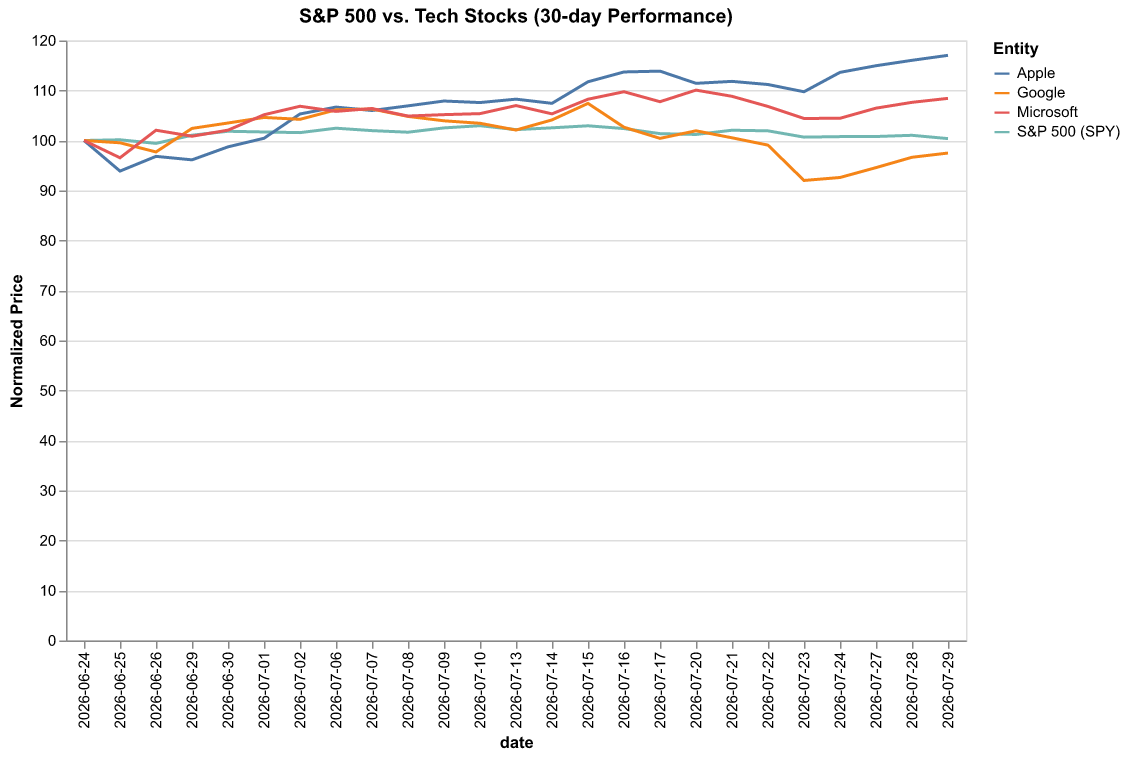

spec saved to output/chart_cf1d089599ec.vl.json, image saved to output/chart_cf1d089599ec.png (159 KB)


In [81]:
chart_result = client.research(
    message="Chart the S&P 500 (SPX) index level over the last 30 days, comparing it with Apple, Google, and Microsoft.",
    research_effort="lite",
    chart_generation=True,
    on_event=make_progress_printer(),
)

print(f"\ncharts returned: {len(chart_result.charts)}")
for chart in chart_result.charts:
    render_chart(chart)

---
## 6. Other output formats

| Method | Returns |
|--------|---------|
| `get_answer()` | Plain answer text |
| `get_answer_with_citations()` | Answer with `[1]`, `[2, 3]` markers |
| `get_markdown_with_citations()` | Answer plus a Sources section |
| `get_numbered_citations()` | Citations numbered to match the inline markers |
| `get_citations()` / `get_citations_json()` | Every document returned by search |
| `to_dict()` / `to_json()` | Full result |
| `to_dict_with_inline_citations()` / `to_json_with_inline_citations()` | Full result, answer annotated |

Pass `include_tool_citations=False` to any of the citation methods for a document-only reference list.

In [82]:
# Plain answer, no markers
print(result.get_answer()[:400], "...\n")

# Document citations only, in Bigdata.com citation format
citations = result.get_citations()
print(f"{len(citations)} documents collected from search\n")
print(json.dumps(citations[0], indent=2)[:900], "...")

### Executive Summary
The Nasdaq 100 index is experiencing a period of heightened volatility, reflecting a broader structural rotation away from the tech-heavy concentration that drove the first-half gains of 2026. As of July 29, 2026, the index sits at 27,534.46, with significant downward pressure in the last month (-7.52%) as investors reassess the durability of AI-driven earnings and broader ma ...

32 documents collected from search

{
  "id": "4F99068FBFD81D86A76D1439E2618C18",
  "headline": "How do the portfolio adjustments of actively managed funds differ given the concentration of U.S. tech giants?",
  "timestamp": "2026-07-24T08:52:06",
  "source": {
    "id": "4A99A9",
    "name": "Sina (\u65b0\u6d6a)",
    "rank": "RANK_4"
  },
  "url": "http://cj.sina.com.cn/articles/view/5570287027/14c03d5b300101nxy8",
  "source_type": "BIGDATA",
  "chunks": [
    {
      "cnum": 1,
      "text": "In the first half of 2026, the Nasdaq 100 index rose by approximately 20%, but the vast major

---
## 7. Save results

In [83]:
outputs = {
    "output/citations.json": result.get_citations_json(),
    "output/research_result.json": result.to_json(),
    "output/result_with_inline_citations.json": result.to_json_with_inline_citations(),
}

for path, content in outputs.items():
    with open(path, "w") as fh:
        fh.write(content)
    print(f"saved {path} ({len(content):,} bytes)")

saved output/citations.json (59,776 bytes)
saved output/research_result.json (65,406 bytes)
saved output/result_with_inline_citations.json (36,909 bytes)


---
## 8. Follow-up questions

`follow_up()` reuses the previous result's `chat_id`, so the agent keeps the earlier turns in context. This requires `persistence_mode="enabled"` on the client; with the API default of `"disabled"` no history is saved and the follow-up starts cold.

In [84]:
follow_up_result = client.follow_up(
    "Which sectors are driving that performance?",
    previous_result=result,
    research_effort="lite",
)

print(f"same conversation: {follow_up_result.chat_id == result.chat_id}\n")
display(Markdown(follow_up_result.get_answer_with_citations()))

same conversation: True



The Nasdaq 100's performance is currently defined by a divergence between its long-term Year-to-Date (YTD) drivers and its recent 1-month market rotation.

### **Long-Term Drivers (YTD)**
The index's YTD gain of **+9.05%** has been primarily driven by the **Technology sector**, which remains up **+17.40%** YTD [1]. Semiconductor companies and mega-cap technology firms were the dominant contributors to the index's growth through the first half of 2026 [2].

### **Recent Drivers (1-Month Performance)**
In the last month, the market leadership has shifted as investors rotate capital out of high-valuation tech and into more defensive or cyclical areas.

*   **Laggards (Dragging Performance):** The **Technology sector** has faced significant selling pressure, declining **-8.84%** over the past month [1]. Semiconductor stocks, previously the engine of the Nasdaq 100's rally, have been a specific point of weakness—often described in recent commentary as "cratering" amid AI financing concerns [3].
*   **New Leaders (Recent Strength):** Capital is currently flowing into sectors that have demonstrated resilience or positive momentum during the recent drawdown:
    *   **Energy (+9.50%):** Leading gains over the last month [1].
    *   **Health Care (+3.95%):** Showing relative strength as a defensive play [1].
    *   **Communication Services (+1.84%):** Has outperformed the broader tech index, recently leading daily gains [1, 3].
    *   **Consumer Staples (+3.74%)** and **Consumer Discretionary (-3.99% but outperforming the broader tech slide):** Both have been cited as areas of rotation as analysts advocate for a "broadening of market leadership" beyond the traditional tech giants [1, 4].

In essence, while Technology remains the primary historical driver of the index's 2026 performance, the current trend is characterized by a rotation toward Energy and defensive sectors as the market reassesses the sustainability of the "AI trade" [3, 4].

In [85]:
numbered_citations = follow_up_result.get_numbered_citations()

display(Markdown(f"---\n## References ({len(numbered_citations)})\n"))
print_citation(numbered_citations)

---
## References (4)


**[1]** get_market_tearsheet<br>Bigdata.com tool &nbsp;`get_market_tearsheet`

---

**[2]** Nasdaq 100 Flashes Warning Signs After 5-Day Slide: Is The Tech Rally Running Out Of Steam?<br>Benzinga &nbsp;|&nbsp; Jun 29, 2026<br>[https://www.benzinga.com/node/60149061?utm_campaign=partner_feed&utm_m](https://www.benzinga.com/node/60149061?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack)

> *The 10 best-performing stocks in the Nasdaq 100 in 2026. Read Also: After The June Swoon, Could July Deliver A Breakout Rally? Carson Group Strategist Ryan Detrick Says This Rare S&P 500 Signal Has Never Failed Unprecedented Volatility Disconnect While tech indexes slip, options markets are flashing...*

---

**[3]** Oil Crashes 8%, Chip Rout Weighs on Nasdaq 100: Stock Market Today<br>Benzinga &nbsp;|&nbsp; Jul 27, 2026<br>[https://www.benzinga.com/node/60706041?utm_campaign=partner_feed&utm_m](https://www.benzinga.com/node/60706041?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack)

> *Monday's Performance In Major U.S. Indices Index ! Change |- | S&P 500 | 7,391.14 | -0.3% |- | Dow Jones | 52,117.67 | +0.3% |- | Nasdaq 100 | 27,821.55 | -1.1% |- | Russell 2000 | 2,933.77 | +0.1% |} According to the Benzinga Pro platform: The Vanguard S&P 500 ETF (NYSE:VOO) slipped 0.3%. The SPDR ...*

---

**[4]** Traders on Kalshi think the Nasdaq-100 will end 2026 above 30,000, predicting a cooler second half of the year<br>CNBC &nbsp;|&nbsp; Jul 07, 2026<br>[https://www.cnbc.com/2026/07/07/traders-on-kalshi-think-the-nasdaq-100](https://www.cnbc.com/2026/07/07/traders-on-kalshi-think-the-nasdaq-100-will-end-2026-above-30000.html)

> *The Nasdaq-100's big run up in 2026 came after the U.S. stock market hit its Iran war-induced lows on March 30. Between then and June 2, the index, comprised of the 100 largest non-financial stocks on Nasdaq, surged more than 33% amid renewed confidence in the artificial intelligence trade. Fading c...*

---

---
## 9. Error handling

Failures arrive in two layers, and they need different treatment.

**HTTP level** - raised before the stream starts, mapped to typed exceptions:

| Status | Exception | Retryable |
|-------:|-----------|-----------|
| `400` / `422` | `InvalidRequestError` | No |
| `401` | `AuthenticationError` | No |
| `403` | `EntitlementError` | No |
| `404` | `ResourceNotFoundError` | No |
| `429` | `RateLimitError` | Yes, with backoff |
| `5xx` | `ServerError` | Yes, with backoff |

**Stream level** - typed messages inside a `200` response:

| Message | Handling |
|---------|----------|
| `LLM_RETRY` | Logged. The agent recovers on its own |
| `TOOL_ERROR` | Counted in `result.tool_errors`, never raised. Check it to detect a degraded answer |
| `ERROR` | Raised as `StreamError`. The stream is over |
| No `COMPLETE` | Raised as `TruncatedStreamError`, so a truncated stream never looks like an empty answer |

All of these derive from `ResearchAgentError`.

In [15]:
from research_client import ResearchAgentError

# A rejected credential surfaces as a typed exception before the stream starts,
# rather than as a silently empty answer. The API answers 401 or 403 depending
# on whether the key is malformed or simply unknown.
try:
    ResearchClient(api_key="not-a-real-key").research("test", research_effort="lite")
except ResearchAgentError as exc:
    print(f"{type(exc).__name__}: {exc}")

EntitlementError: Not entitled to this resource (403): {"status_code": 403, "message": "Authorization failed for this resource.", "request_id": "019faef4-362f-7323-8c24-71efc756b11e"}


In [16]:
# A degraded answer is visible without inspecting the stream.
if result.tool_errors:
    print("Some sources could not be retrieved; the answer may be incomplete.")
    for tool, count in result.tool_errors.items():
        print(f"  {tool}: {count} failure(s)")
else:
    print("No tool errors - every source was retrieved.")

No tool errors - every source was retrieved.


---
## Citation format reference

Document citations follow the standard Bigdata.com format. Only non-null fields are included.

```json
{
  "number": 2,
  "id": "80CBFA19A18071707AADAC6765E1F9F0",
  "headline": "SC SECTOR WATCH",
  "timestamp": "2026-07-27T10:32:26",
  "source": {"id": "7ED2AF", "name": "S&P Capital IQ NetAdvantage", "rank": "RANK_2"},
  "url": "https://...",
  "source_type": "BIGDATA",
  "chunks": [
    {"cnum": 5, "text": "Relevant excerpt...", "relevance": 0.94, "sentiment": 0.82}
  ]
}
```

Whole-tool attributions use a distinct shape, flagged by `"type": "TOOL"`:

```json
{
  "number": 1,
  "type": "TOOL",
  "tool_name": "get_market_tearsheet",
  "audit_id": "action_70282a87",
  "title": "Market Tearsheet"
}
```

### Source shapes

`source` on a grounding reference is one of two shapes, discriminated on `type`:

| | `BIGDATA` | `EXTERNAL` |
|---|---|---|
| Publisher name | `src_name` | `action.name` |
| URL | `url` | `action.url` |
| Headline | `hd` | `hd` |
| Date | `ts` | `ts` |

Reading only the `BIGDATA` field names is why external web results used to appear without a publisher or link. The client normalises both shapes onto the same `Citation` fields.

### Deduplication

Sources are deduplicated by `id`, falling back to `url`, then `hd`. Headlines are the last resort because unrelated documents can share a title - deduplicating on them merges distinct articles into one reference.